# July runs vs the best September run

**July**: the 2026-07-28 batch (full potential set, `terms2f1130a8`, many seeds) used before the September analyses.
**September**: `schedtest_adaptive_reg1e-4` (same full potential set, adaptive time grid), the best run of the 25-26 September tests.

**The two were fitted on different reference data.** July used `subseries_len=1024` (two Db3 coarse-grainings, n1=5000),
September `subseries_len=512` (one coarse-graining, n1=8500); both end at 256 points. So:
- every statistic is shown **relative to each group's own data** (ratio or difference), never one group against the other's data;
- tau = 1 is 4 original samples for July and 2 for September: this compares how well each run reproduces **its own target**, not which target is more physical.

The July seeds give the seed-to-seed spread (5-95% band), which a single September seed cannot. That band is **not** the uncertainty of the comparison with the data: every seed is compared with the same data.

The **data-noise band** (dotted lines, 'data noise' rows) is: the group's own data split into two random halves `N_NOISE` times, each half compared with the other, 5-95% over the splits, rescaled from n/2 vs n/2 series to the n_run vs n_ref comparison actually made (1/sqrt(2) for equal sizes). A run inside it is as close to its data as the data is to itself. See `data_noise` / `noise_band` in `run_comparison.py`.

Plotting code lives in `run_comparison.py` (`plot_group_*`); this notebook only picks the runs.

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from run_comparison import *

plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})
pd.set_option('display.float_format', '{:.3g}'.format)
pd.set_option('display.max_colwidth', 40)

## Runs

In [2]:
NEW_NAME, NEW_LABEL, NEW_SEED = 'Sep 2ph full', 'schedtest_two_phase_reg1e-4', 900
JULY_NAME, JULY_PATTERN = 'July', '*_n1_5000_lam5e-07_seed_*_terms2f1130a8_20260728_1232*'
N_PDF = 5                  # July seeds pooled in the PDF plots (the September run has 8500 series)
THRESHOLD = 1e-8           # same as --moment_threshold

new_runs, missing = load_runs({NEW_NAME: NEW_LABEL}, seed=NEW_SEED)
if missing:
    print(pull_commands(missing))
    raise RuntimeError(f'{missing} not found locally: pull it first (command above)')
new = new_runs[NEW_NAME]
july_cfgs = find_configs(JULY_PATTERN)
assert july_cfgs, f'no saved samples match {JULY_PATTERN}'
july0 = load_config(july_cfgs[0], extras=False)
print(f"{NEW_NAME}: {new['config']}\n  {tuple(new['xt'].shape)}, {len(new['t']) - 1} steps, "
      f"t_end = {float(new['t'][-1]):.8f}, {new['runtime_h']:.1f} h")
print(f"{JULY_NAME}: {len(july_cfgs)} seeds, e.g. {july_cfgs[0]}\n  {tuple(july0['xt'].shape)}, "
      f"{len(july0['t']) - 1} steps, t_end = {float(july0['t'][-1]):.8f}")

Sep 2ph full: turbulencesynth_M256_J8_Q3_sigma3.5_nt60000_n1_8500_lam0.0_thomas_nsub1_f64_dedupfilt_seed_900_terms2f1130a8_schedtest_two_phase_reg1e-4_20260927_0005
  (8500, 256), 60000 steps, t_end = 0.99995000, 18.5 h
July: 51 seeds, e.g. turbulencesynth_M256_J8_Q3_sigma3.5_nt40000_n1_5000_lam5e-07_seed_300_terms2f1130a8_20260728_1232
  (5000, 256), 39705 steps, t_end = 0.99994558


### What differs between the two set-ups
All `config.json` keys whose values differ (keys absent on one side are shown as `-`).

In [3]:
a, b = july0['cfg'], new['cfg']
skip = {'timestamp', 'config_name', 'seed', 'outdir', 'reg_system_dir'}
diff = {k: (a.get(k, '-'), b.get(k, '-')) for k in sorted(set(a) | set(b))
        if k not in skip and a.get(k, '-') != b.get(k, '-')}
pd.DataFrame(diff, index=[JULY_NAME, NEW_NAME]).T.astype(str)

,July,Sep 2ph full
B,5000,8500
adapt_grow,-,1.2
adapt_h0,-,1e-05
adapt_h_max,-,0.001
adapt_ratio_max,-,0.001
adapt_ratio_min,-,1e-05
adapt_tol,-,0.001
batch_size,nan,5000.0
deduplicate_filters,-,True
gap_end,-,5e-05


## Reference data and statistics
One reference per group, rebuilt from its `config.json` exactly as `run_SDE.py` does. The July statistics are computed seed by seed; the samples (histograms, KS) are kept only for the first `N_PDF` seeds, the other seeds keep their curves, KS row and metrics.

In [4]:
DATA_KEYS = ('n1', 'subseries_len', 'target_len')

x_new, x_jul = reference_data(new['cfg']), reference_data(july0['cfg'])
S_new_ref, S_jul_ref = compute_stats(x_new), compute_stats(x_jul)
print('September data', tuple(x_new.shape), '| July data', tuple(x_jul.shape))

S_jul, ks_jul, m_jul, x_jul_pdf = [], [], [], []
for c in july_cfgs:
    r = load_config(c, extras=False)
    if r['cfg']:
        assert all(r['cfg'].get(k) == july0['cfg'].get(k) for k in DATA_KEYS), f'{c}: different data'
    keep = len(x_jul_pdf) < N_PDF
    S, ks, m = run_summary(compute_stats(r['xt']), S_jul_ref, keep_samples=keep)
    S_jul.append(S); ks_jul.append(ks); m_jul.append(m)
    if keep:
        x_jul_pdf.append(r['xt'].numpy())
S_new, ks_new, m_new = run_summary(compute_stats(new['xt']), S_new_ref)
print(f'{len(S_jul)} July seeds loaded')

September data (8500, 256) | July data (5000, 256)
51 July seeds loaded


### Data-noise bands
`N_NOISE` random half/half splits of each group's data (~3 s per split, run in threads: ~3 min for both groups at N_NOISE = 30).

In [5]:
%%time
N_NOISE = 30         # ~3 s per split and group; 50 for final figures
groups = {
    JULY_NAME: dict(ref=S_jul_ref, runs=S_jul, ks=ks_jul, metrics=m_jul, color=PALETTE[1],
                    noise=data_noise(x_jul, N_NOISE)),
    NEW_NAME: dict(ref=S_new_ref, runs=[S_new], ks=[ks_new], metrics=[m_new], color=PALETTE[0],
                   noise=data_noise(x_new, N_NOISE)),
}

CPU times: user 1min 44s, sys: 22.9 s, total: 2min 7s
Wall time: 17.5 s


## Summary
Each metric against the group's own data (ratios: 1 = perfect; `skew_diff` = gen - data; KS = Kolmogorov-Smirnov distance; `*_logrms` = rms of log(gen / data)).
July: median [5%, 95%] across seeds. A September value inside the July interval is not distinguishable from July at one seed.
`data noise` rows: 5-95% of the rescaled data-noise spread for ratios and differences, its 95th percentile for distances (`< value`).
`spec_logrms` is over the raw rfft bins (half of them in the top octave); `spec_logrms_oct` over log-spaced bands, every octave weighted equally. `wav_E_logrms` / `wav_flat_logrms`: the same for the Morlet band energy / flatness below.

In [6]:
group_summary(groups)

,S2_ratio_tau1,flat4_ratio_tau1,flat6_ratio_tau1,skew_tau1,skew_diff_tau1,spec_logrms,spec_logrms_oct,wav_E_logrms,wav_flat_logrms,marg_KS,wav_KS_max
July (n=51),"0.972 [0.97, 0.973]","1.03 [1.02, 1.04]","1.22 [1.16, 1.28]","0.0114 [-0.0579, 0.0642]","-0.0274 [-0.0968, 0.0253]","0.934 [0.927, 0.94]","0.476 [0.471, 0.478]","0.509 [0.504, 0.513]","0.846 [0.839, 0.855]","0.0193 [0.015, 0.027]","0.782 [0.781, 0.784]"
data noise (July),"[0.953, 1.03]","[0.833, 1.2]","[0.597, 1.91]",-,"[-0.0867, 0.0759]",< 0.167,< 0.101,< 0.0999,< 0.264,< 0.0144,< 0.0403
Sep 2ph full (n=1),0.952,1.03,1.02,-0.0972,-0.0688,0.419,0.233,0.248,0.329,0.015,0.312
data noise (Sep 2ph full),"[0.958, 1.04]","[0.814, 1.21]","[0.532, 1.66]",-,"[-0.132, 0.131]",< 0.249,< 0.17,< 0.161,< 0.583,< 0.0124,< 0.0424


## Time series
Same y-scale within each block, not across the two (different data).

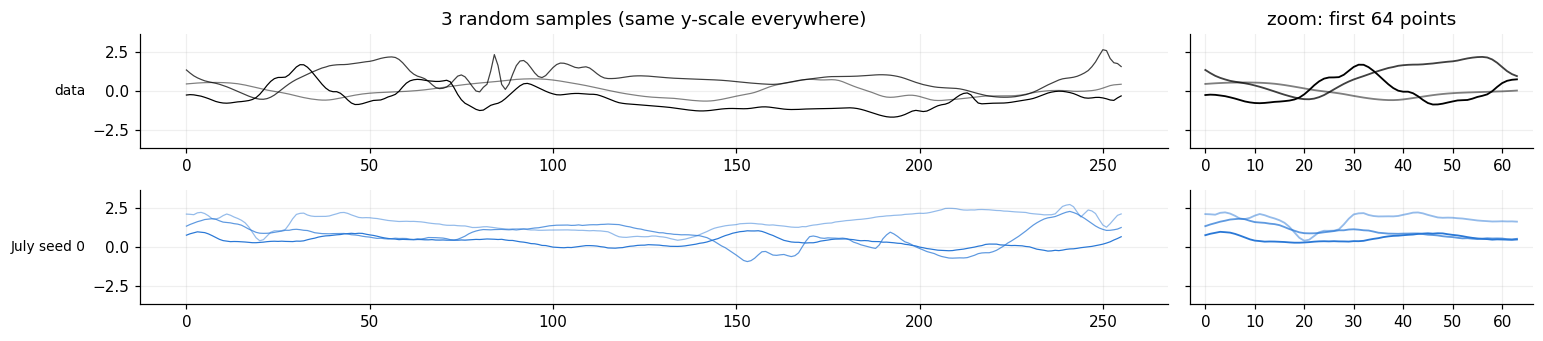

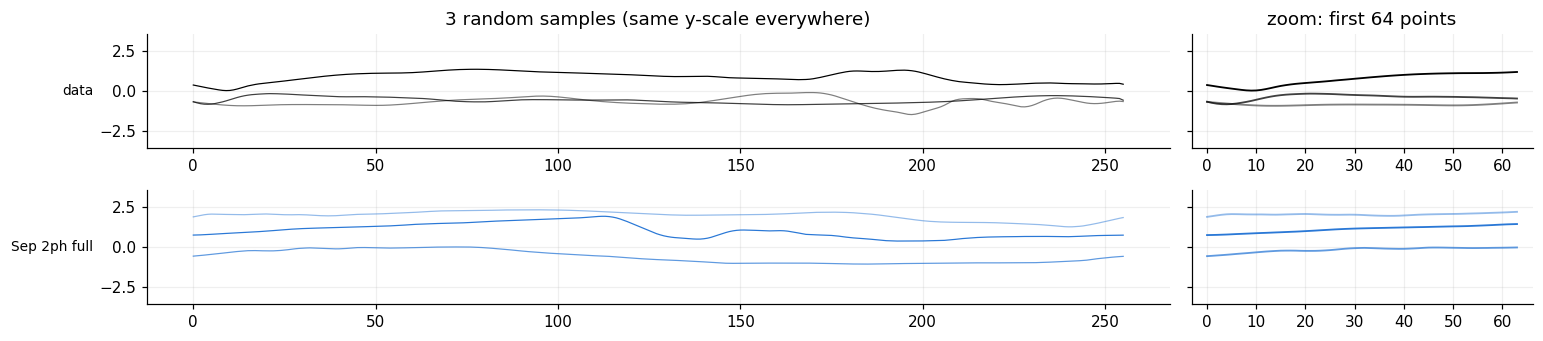

In [7]:
plot_time_series(x_jul, {f'{JULY_NAME} seed 0': dict(xt=torch.as_tensor(x_jul_pdf[0]))}, n=3, zoom=64)
plot_time_series(x_new, {NEW_NAME: new}, n=3, zoom=64)

In [ ]:
# Extreme events: acceleration a(t) = x(t+1) - x(t) (periodic), in units of the DATA's rms acceleration.
# A series is extreme if its largest |a| exceeds the PCT-th percentile of the same quantity over the
# DATA series; the same (data) threshold is applied to the generated series. By construction ~(100-PCT)%
# of the data series qualify: compare the generated fraction with that.
PCT = 99           # percentile of the data's per-series max |a|
N_SHOW = 20         # figures per source, largest events first (None = all above threshold)
YLIM = (-4, 4)      # x range, the same for every figure (None = automatic)
A_YLIM = (-45, 45)  # a / sigma range, the same for every figure (None = automatic)

def extreme_events(sources, x_data, pct=PCT, n_show=N_SHOW, ylim=YLIM, a_ylim=A_YLIM):
    """sources: {name: (series (B, T), colour)}; x_data: the reference data of these sources."""
    as_np = lambda v: v.numpy() if torch.is_tensor(v) else np.asarray(v)
    xd = as_np(x_data)
    ad = np.roll(xd, -1, axis=1) - xd
    sigma = np.sqrt(np.mean(ad ** 2))
    thr = np.percentile(np.abs(ad).max(1) / sigma, pct)
    for name, (x, color) in sources.items():
        x = as_np(x)
        a = (np.roll(x, -1, axis=1) - x) / sigma
        peak, pos = np.abs(a).max(1), np.abs(a).argmax(1)
        sel = np.argsort(-peak)
        sel = sel[peak[sel] > thr]
        print(f'{name}: {len(sel)} of {len(x)} series ({100 * len(sel) / len(x):.2f}%) have max |a| > '
              f'{thr:.1f} sigma (data {pct}th percentile); largest event {peak.max():.1f} sigma')
        for i in sel[:n_show]:
            fig, (a1, a2) = plt.subplots(2, 1, figsize=(11, 4), sharex=True,
                                         gridspec_kw=dict(height_ratios=[3, 2]))
            a1.plot(x[i], color=color, lw=1.2)
            a2.plot(a[i], color=color, lw=1)
            for ax in (a1, a2):
                ax.axvline(pos[i], color='k', lw=0.8, ls=':')
                ax.grid(alpha=0.2)
            for s in (thr, -thr):
                a2.axhline(s, color='0.5', lw=0.8, ls='--')
            if ylim is not None:
                a1.set_ylim(ylim)
            if a_ylim is not None:
                a2.set_ylim(a_ylim)
            a1.set_ylabel('x'); a2.set_ylabel(r'$a / \sigma_a^{data}$'); a2.set_xlabel('t')
            a1.set_title(f'{name}, series {i}: max |a| = {peak[i]:.1f} sigma at t = {pos[i]}', fontsize=10)
            fig.tight_layout()
            plt.show()

extreme_events({'Sep data': (x_new, 'black'), NEW_NAME: (new['xt'], PALETTE[0])}, x_new)
extreme_events({'July data': (x_jul, 'black'),
                **{f'July seed {k}': (xs, PALETTE[1]) for k, xs in enumerate(x_jul_pdf)}}, x_jul)

## Power spectrum
Left: raw rfft bins. Right: averaged over log-spaced bands (4 per octave), which removes most of the bin-to-bin scatter. Dotted: data-noise band.

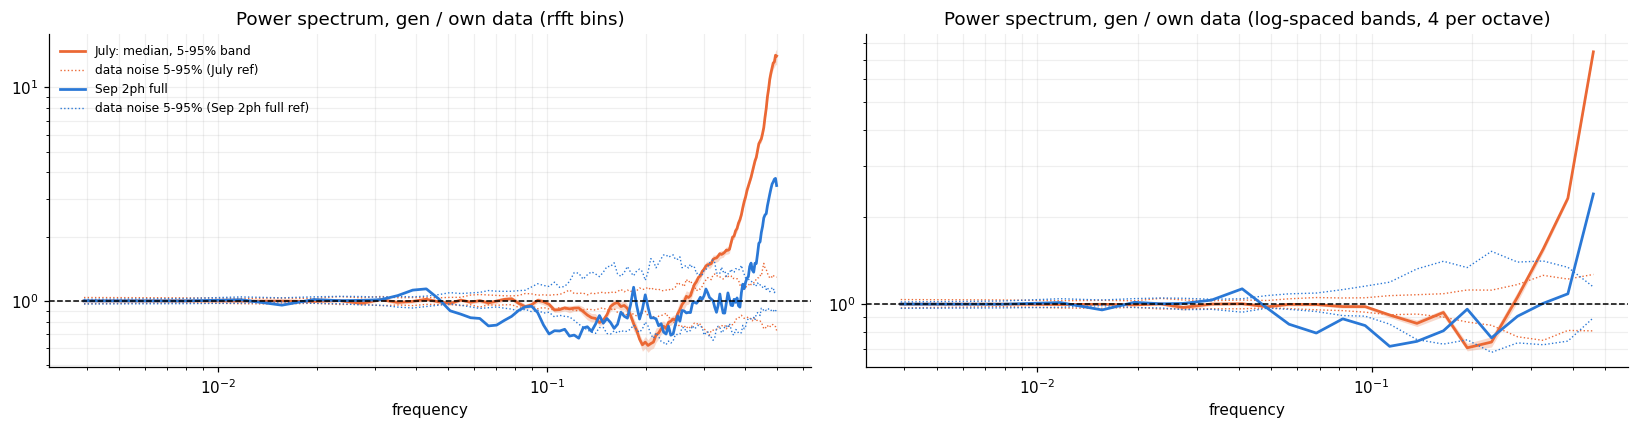

In [8]:
plot_group_spectra(groups)

## Structure functions, flatness, skewness
Skewness is shown as a difference: at these sample sizes it is dominated by noise (compare with the dotted data-noise band).

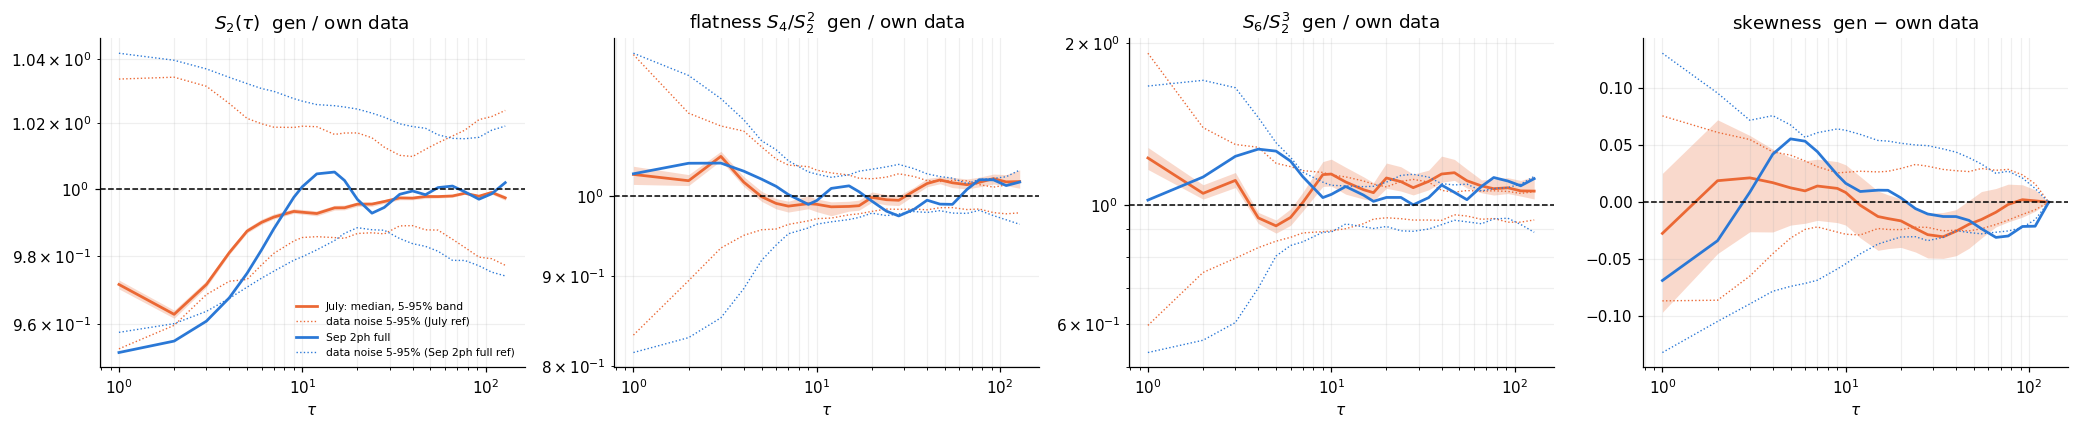

In [9]:
plot_group_structure(groups)

## Scale-by-scale wavelet moments
psi coefficients W (Morlet, Q=3: the first 18 bands of the runs' psi bank, all series), gen / own data against each band's centre frequency: energy E|W|^2 (a wavelet spectrum), flatness E|W|^4 / (E|W|^2)^2 (intermittency at that scale), sparsity (E|W|)^2 / E|W|^2 (lower = sparser).
**In-sample:** these are the bands that `Scalar_psi_gaussianK` (region statistics of |W|, after pruning) and `L_6_psi` constrain.

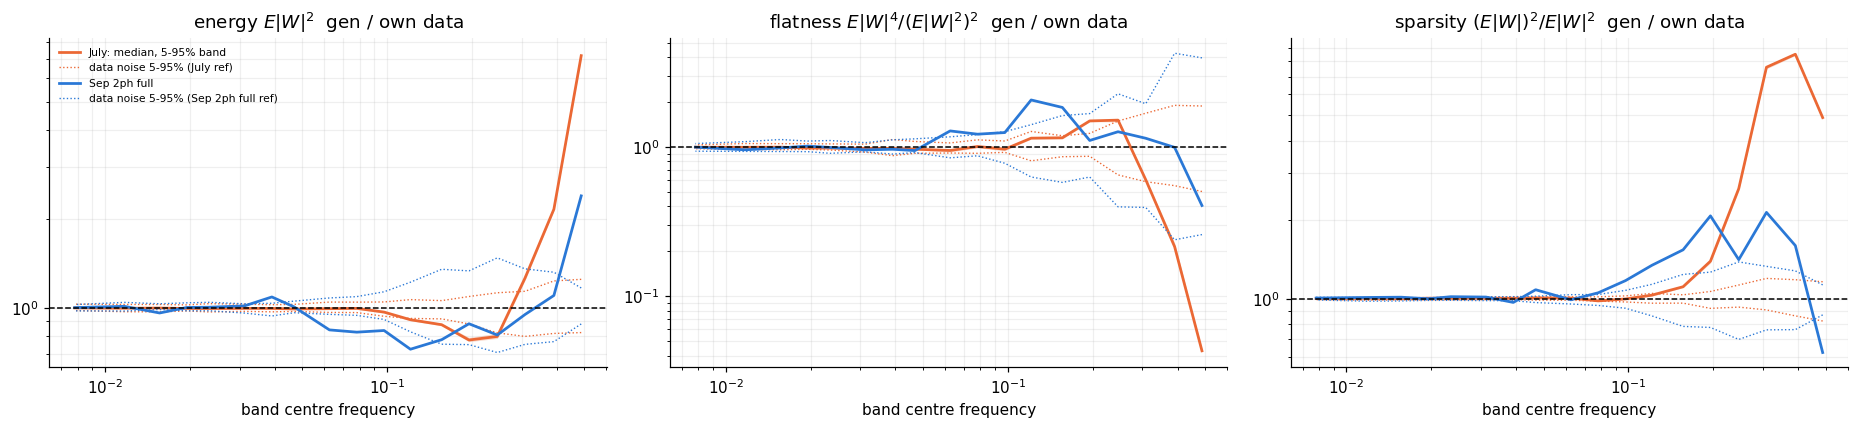

In [10]:
plot_group_band_moments(groups)

## Marginal and increment PDFs

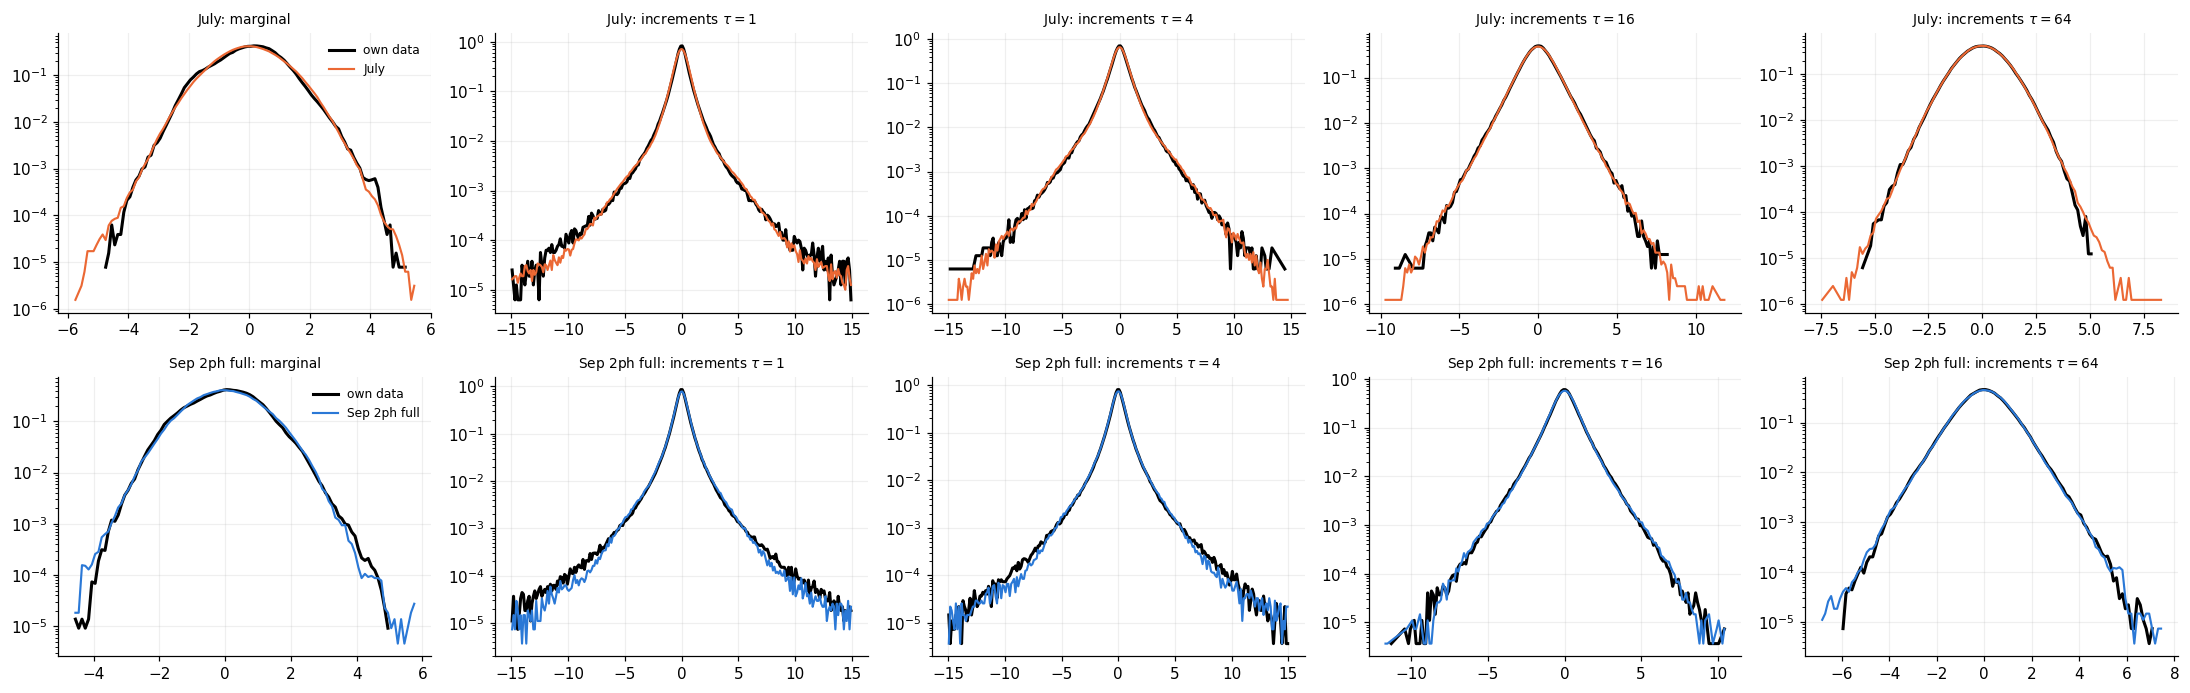

In [11]:
plot_group_pdfs(groups, {JULY_NAME: (x_jul, x_jul_pdf), NEW_NAME: (x_new, [new['xt'].numpy()])})

## Wavelet coefficients: histograms and band mismatch
As `hist_plot` (`codes/check_moments.py`, saved by every run as `figures/histograms.png`), one column per group: data vs generated per band, log density, raw Re W, 2000 series each side (July: its `N_PDF` seeds pooled).
- `psi`: Morlet Q=3, all 24 bands of the runs' psi bank (`Scalar_psi_*`, `L_6_psi`); the last bands repeat the same centre frequency, the runs drop exact copies (`--deduplicate_filters`).
- `morlet`: Morlet Q=1, 8 bands (`Scalar_morlet_*`, `L_6`).

Both are constrained by the potentials, so these histograms are in-sample. `kind='abs'` shows |W| instead (what the region potentials see); `bands=['j0q1', ...]` picks bands.

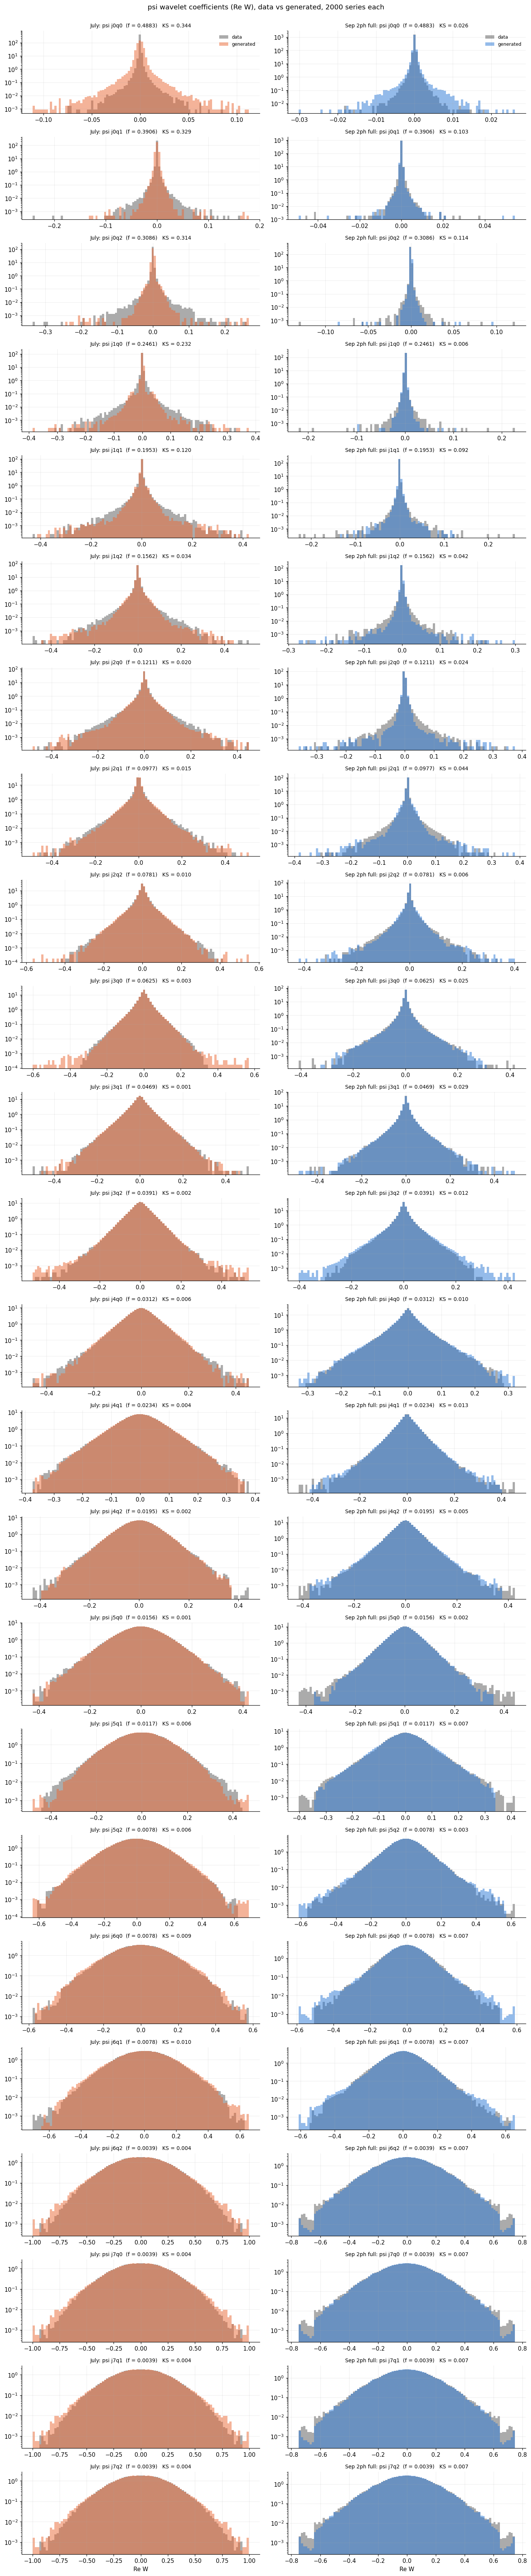

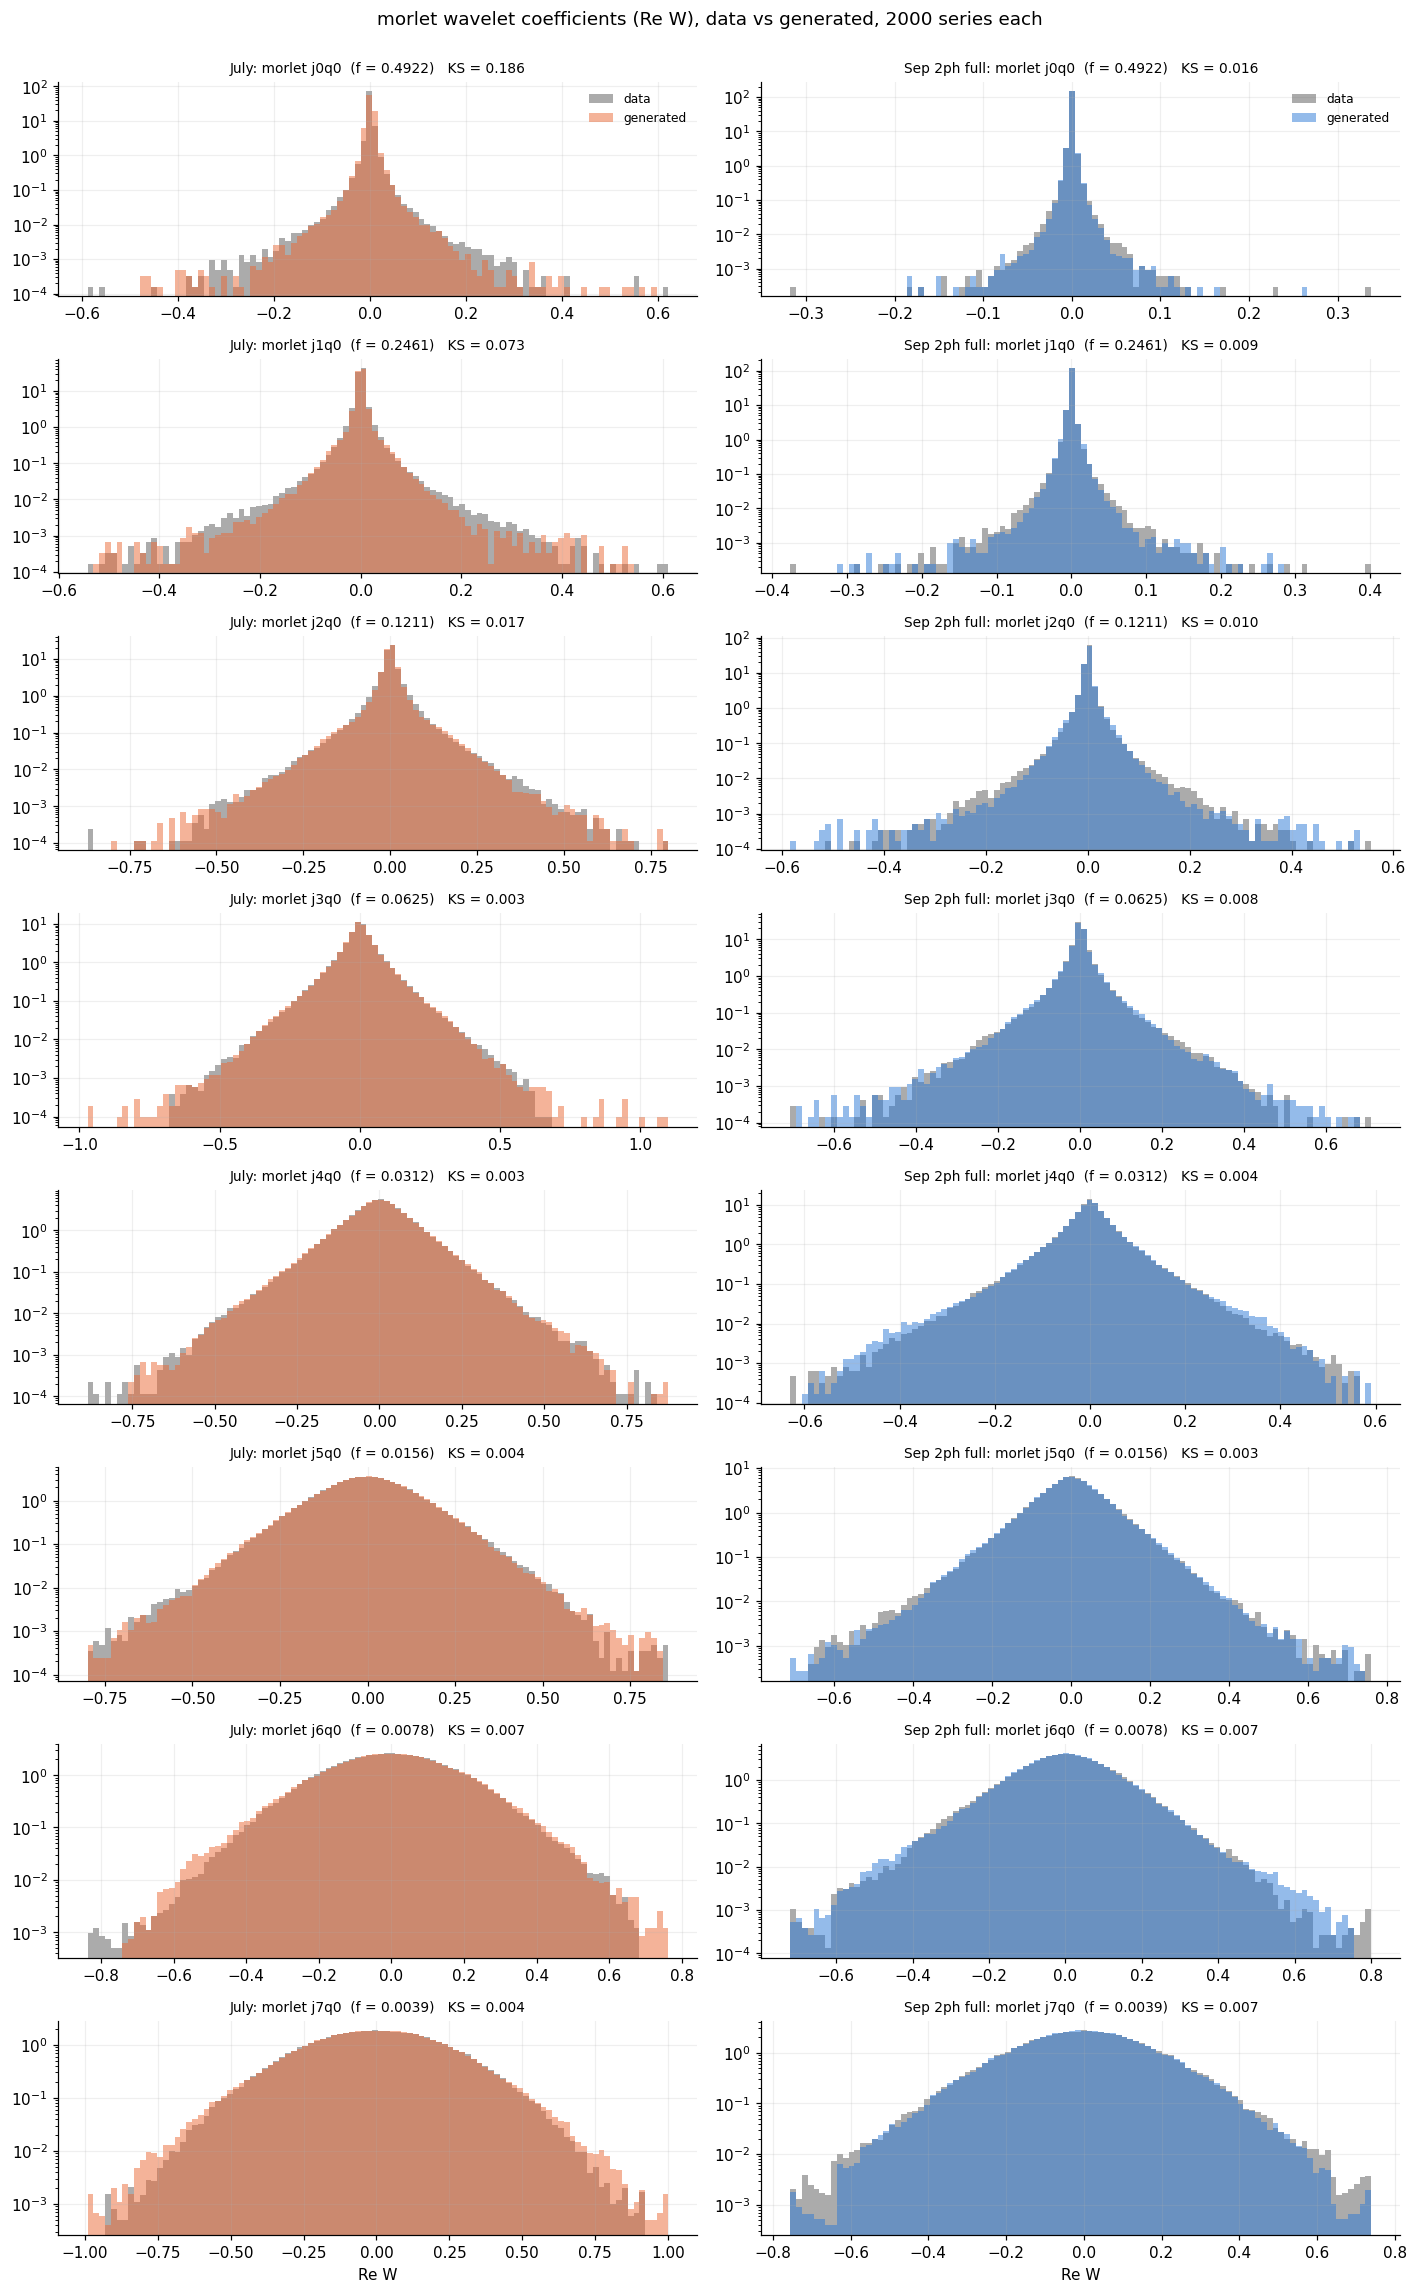

In [12]:
PAIRS = {JULY_NAME: (x_jul, x_jul_pdf), NEW_NAME: (x_new, new['xt'])}
COLORS = {JULY_NAME: PALETTE[1], NEW_NAME: PALETTE[0]}
plot_band_hists(PAIRS, bank='psi', colors=COLORS)
plot_band_hists(PAIRS, bank='morlet', colors=COLORS)

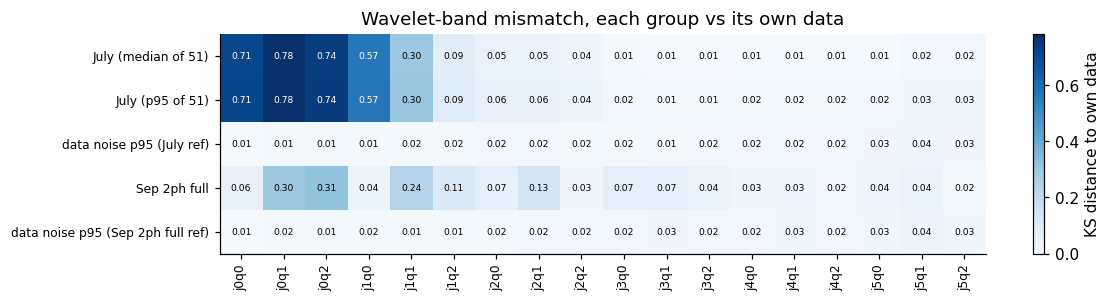

In [13]:
ks_table = plot_group_wavelet_ks(groups)

## Moment matching (only where aux moments are available)
The two runs match different moment sets (different reference data and fitted potentials), so compare the shapes of the curves, not the values moment by moment. The July aux moments may only exist on Jean Zay.

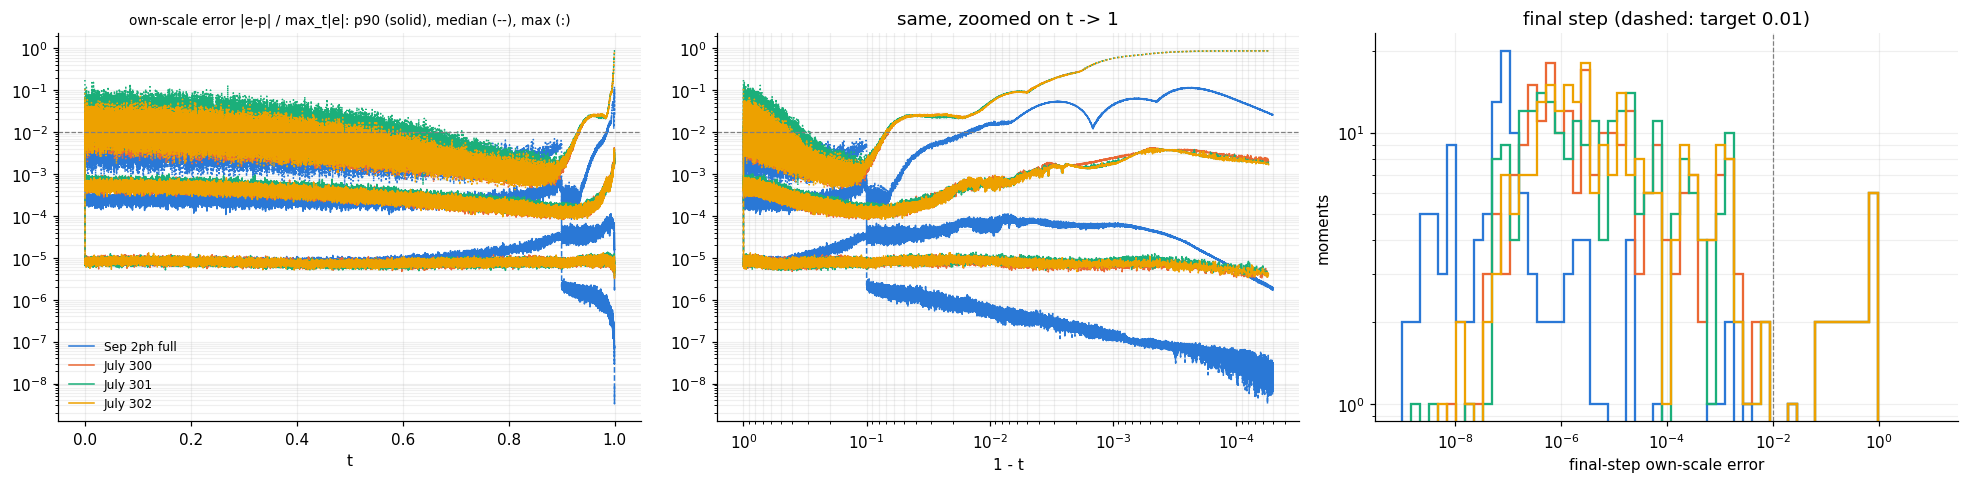

In [14]:
mm_runs = {NEW_NAME: new}
for c in july_cfgs[:3]:
    r = load_config(c)
    if 'barphi_e' in r:
        mm_runs[f"{JULY_NAME} {c.split('_seed_')[1].split('_')[0]}"] = r
if len(mm_runs) == 1:
    print('no July aux moments found locally')
plot_moment_matching(mm_runs, THRESHOLD)